In [12]:
import numpy as np, os, math, time, random
from collections import defaultdict
import matplotlib.pyplot as plt

NPZ = "cora_np.npz"
SEED = 123
np.random.seed(SEED)
random.seed(SEED)


def export_cora_npz(out=NPZ):
    from torch_geometric.datasets import Planetoid
    ds = Planetoid(root="data/Cora", name="Cora")
    data = ds[0]
    N = data.num_nodes
    adj = np.zeros((N,N), dtype=np.float32)
    ei = data.edge_index.numpy()
    adj[ei[0], ei[1]] = 1.0
    # make undirected
    adj = np.maximum(adj, adj.T)
    np.savez(out,
             adj=adj,
             features=data.x.numpy().astype(np.float32),
             labels=data.y.numpy().astype(int))
    print("Exported", out)

if not os.path.exists(NPZ):
    try:
        export_cora_npz(NPZ)
    except Exception as e:
        raise RuntimeError("Failed to export dataset via PyG. Install torch_geometric or provide NPZ.") from e


# 2) Load data
def load_data(npz_path):
    data = np.load(npz_path, allow_pickle=True)
    A = data["adj"].astype(np.float32)
    X = data["features"].astype(np.float32)
    y = data["labels"].astype(int)
    return A, X, y

A, X, y = load_data(NPZ)
N = A.shape[0]
print("Loaded dataset:", NPZ)
print("  Nodes (N):", N)
print("  Features (F):", X.shape[1])
print("  Classes (C):", int(y.max())+1)


# Utilities

def normalize_adj(A):
    A = A + np.eye(A.shape[0], dtype=np.float32)
    deg = A.sum(axis=1)
    deg_inv_sqrt = 1.0 / np.sqrt(np.maximum(deg, 1e-12))
    D = np.diag(deg_inv_sqrt)
    return D @ A @ D

def upper_edge_list_from_adj(A):
    rows, cols = np.where(np.triu(A, k=1) > 0)
    return list(zip(rows.tolist(), cols.tolist()))

def make_train_val_test_edge_splits(A, val_frac=0.10, test_frac=0.10, seed=SEED):
    edges = upper_edge_list_from_adj(A)
    rng = np.random.RandomState(seed)
    idx = np.arange(len(edges))
    rng.shuffle(idx)
    n = len(edges)
    n_test = int(round(n * test_frac))
    n_val = int(round(n * val_frac))
    # ensure at least one in each if possible
    n_test = max(1, n_test) if n > 2 else n_test
    n_val = max(1, n_val) if n > 2 else n_val
    test_idx = idx[:n_test]
    val_idx = idx[n_test:n_test+n_val]
    train_idx = idx[n_test+n_val:]
    pos_test = [edges[i] for i in test_idx]
    pos_val = [edges[i] for i in val_idx]
    pos_train = [edges[i] for i in train_idx]
    # remove val/test edges from training adjacency
    A_train = A.copy()
    for (u,v) in pos_test + pos_val:
        A_train[u,v] = 0
        A_train[v,u] = 0
    return A_train, pos_train, pos_val, pos_test

def sample_negative_edges(A, k, forbidden_set=None, seed=None):
    rng = np.random.RandomState(seed)
    negs = []
    forbidden = set(forbidden_set) if forbidden_set is not None else set()
    tries = 0
    maxtries = k * 20 + 1000
    N = A.shape[0]
    while len(negs) < k and tries < maxtries:
        u = int(rng.randint(0, N)); v = int(rng.randint(0, N))
        if u == v:
            tries += 1; continue
        if u > v: u,v = v,u
        if A[u,v] != 0:
            tries += 1; continue
        if (u,v) in forbidden:
            tries += 1; continue
        negs.append((u,v)); forbidden.add((u,v)); tries += 1
    if len(negs) < k:
        for i in range(N):
            for j in range(i+1, N):
                if A[i,j] == 0 and (i,j) not in forbidden:
                    negs.append((i,j)); forbidden.add((i,j))
                    if len(negs) >= k: break
            if len(negs) >= k: break
    return negs[:k]

# simple helpers
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def compute_auc(labels, scores):
    idx = np.argsort(-scores)
    lab = np.asarray(labels)[idx]
    tp = 0; fp = 0
    P = lab.sum(); Nneg = len(lab) - P
    if P == 0 or Nneg == 0: return float('nan')
    tpr = []; fpr = []
    for l in lab:
        if l == 1: tp += 1
        else: fp += 1
        tpr.append(tp / P); fpr.append(fp / Nneg)
    fpr = np.array([0.0] + fpr + [1.0])
    tpr = np.array([0.0] + tpr + [1.0])
    return np.trapz(tpr, fpr)

# GCN encoder (NumPy)

class GCNEncoder:
    def __init__(self, in_dim, hidden_dim, out_dim, seed=SEED, weight_scale=1.0):
        rng = np.random.RandomState(seed)
        self.W0 = rng.randn(in_dim, hidden_dim).astype(np.float32) * math.sqrt(2.0 / max(1,in_dim)) * weight_scale
        self.b0 = np.zeros(hidden_dim, dtype=np.float32)
        self.W1 = rng.randn(hidden_dim, out_dim).astype(np.float32) * math.sqrt(2.0 / max(1,hidden_dim)) * weight_scale
        self.b1 = np.zeros(out_dim, dtype=np.float32)
        self.cache = {}
        self.grads = {}

    def forward(self, X, A_hat):
        H1_pre = A_hat @ X @ self.W0 + self.b0  # (N,hidden)
        H1 = np.maximum(0.0, H1_pre)
        E = A_hat @ H1 @ self.W1 + self.b1     # (N,out)
        # cache for backward
        self.cache['X'] = X; self.cache['H1_pre'] = H1_pre; self.cache['H1'] = H1; self.cache['E'] = E
        return E

    def backward_from_embedding_grads(self, dE, A_hat, weight_decay=5e-4):
        H1 = self.cache['H1']
        X = self.cache['X']
        # dW1 = H1^T @ (A_hat^T @ dE) + wd * W1
        dW1 = H1.T @ (A_hat.T @ dE) + weight_decay * self.W1
        db1 = dE.sum(axis=0)
        # dH1 = (A_hat^T @ dE) @ W1^T
        dH1 = (A_hat.T @ dE) @ self.W1.T
        # ReLU backprop
        dH1[self.cache['H1_pre'] <= 0] = 0
        dW0 = X.T @ (A_hat.T @ dH1) + weight_decay * self.W0
        db0 = dH1.sum(axis=0)
        self.grads = {'dW0': dW0, 'db0': db0, 'dW1': dW1, 'db1': db1}
        return [dW0, db0, dW1, db1]

# Decoder / loss
def edge_scores_from_embeddings(E, edge_list):
    if len(edge_list) == 0:
        return np.array([])
    u = np.array([e[0] for e in edge_list], dtype=np.int64)
    v = np.array([e[1] for e in edge_list], dtype=np.int64)
    return np.sum(E[u] * E[v], axis=1)

def bce_loss_and_grad_logits(logits, labels):
    probs = sigmoid(logits)
    eps = 1e-12
    loss = - np.mean(labels * np.log(np.clip(probs, eps, 1.0)) + (1-labels) * np.log(np.clip(1-probs, eps, 1.0)))
    dlogits = (probs - labels) / max(1, len(labels))
    return loss, dlogits


# Optimizer: simple SGD

class SGD:
    def __init__(self, params, lr=0.01, weight_decay=0.0):
        self.params = params
        self.lr = lr
        self.wd = weight_decay
    def step(self, grads):
        for p, g in zip(self.params, grads):
            if g is None: continue
            if self.wd != 0.0:
                g = g + self.wd * p
            p -= self.lr * g


# Datasets / helpers for linkpred
def make_edge_dataset(pos_list, neg_list):
    edges = pos_list + neg_list
    labels = np.array([1]*len(pos_list) + [0]*len(neg_list), dtype=np.float32)
    return edges, labels

# Training function (AUC-only, records per-epoch AUC histories)
def train_linkpred(A, X, epochs=300, batch_size=256, hidden_dim=128, emb_dim=64, lr=0.01, verbose=True):
    # create train/val/test positive splits and remove val/test from adjacency for encoder
    A_train, pos_train, pos_val, pos_test = make_train_val_test_edge_splits(A, val_frac=0.10, test_frac=0.10, seed=SEED)
    all_pos = set(pos_train) | set(pos_val) | set(pos_test)
    neg_train = sample_negative_edges(A, len(pos_train), forbidden_set=all_pos, seed=SEED+1)
    neg_val = sample_negative_edges(A, len(pos_val), forbidden_set=all_pos.union(set(neg_train)), seed=SEED+2)
    neg_test = sample_negative_edges(A, len(pos_test), forbidden_set=all_pos.union(set(neg_train)).union(set(neg_val)), seed=SEED+3)

    # adjacency used by encoder (train-only edges)
    A_enc = A_train.copy()
    A_hat = normalize_adj(A_enc)

    enc = GCNEncoder(in_dim=X.shape[1], hidden_dim=hidden_dim, out_dim=emb_dim, seed=SEED)
    params = [enc.W0, enc.b0, enc.W1, enc.b1]
    opt = SGD(params, lr=lr, weight_decay=5e-4)

    train_edges, train_labels = make_edge_dataset(pos_train, neg_train)
    val_edges, val_labels = make_edge_dataset(pos_val, neg_val)
    test_edges, test_labels = make_edge_dataset(pos_test, neg_test)

    # print dataset sizes
    print("Positive train/val/test:", len(pos_train), len(pos_val), len(pos_test))
    print("Negative train/val/test:", len(neg_train), len(neg_val), len(neg_test))
    print("Total train/val/test pairs:", len(train_edges), len(val_edges), len(test_edges))

    # shuffle train
    perm = np.random.permutation(len(train_edges))
    train_edges = [train_edges[i] for i in perm]
    train_labels = train_labels[perm]

    # histories (AUC-only)
    train_loss_history = []
    val_loss_history = []
    val_auc_history = []
    test_auc_history = []
    best_val_auc = -1.0
    best_state = None
    best_test_at_val = None

    for epoch in range(1, epochs+1):
        t0 = time.time()
        total_loss = 0.0
        num_batches = math.ceil(len(train_edges) / batch_size)
        for b in range(num_batches):
            s = b * batch_size; e = min(len(train_edges), s + batch_size)
            batch_edges = train_edges[s:e]
            batch_labels = train_labels[s:e]

            # forward
            E = enc.forward(X, A_hat)   # (N,emb)
            logits = edge_scores_from_embeddings(E, batch_edges)
            loss, dlogits = bce_loss_and_grad_logits(logits, batch_labels)
            total_loss += loss * len(batch_labels)

            # compute dE from edge grads (vectorized accumulation)
            dE = np.zeros_like(E, dtype=np.float32)
            if len(batch_edges) > 0:
                u = np.array([e0 for e0, _ in batch_edges], dtype=np.int64)
                v = np.array([e1 for _, e1 in batch_edges], dtype=np.int64)
                coef = dlogits.reshape(-1,1)   # (B,1)
                np.add.at(dE, u, coef * E[v])
                np.add.at(dE, v, coef * E[u])

            # backprop into encoder params
            grads = enc.backward_from_embedding_grads(dE, A_hat, weight_decay=5e-4)
            opt.step(grads)

        avg_loss = total_loss / max(1, len(train_edges))

        # eval on full E
        E_eval = enc.forward(X, A_hat)
        val_logits = edge_scores_from_embeddings(E_eval, val_edges)
        val_loss, _ = bce_loss_and_grad_logits(val_logits, val_labels)
        test_logits = edge_scores_from_embeddings(E_eval, test_edges)
        test_loss, _ = bce_loss_and_grad_logits(test_logits, test_labels)

        # AUCs only
        val_probs = sigmoid(val_logits)
        test_probs = sigmoid(test_logits)
        val_auc = compute_auc(val_labels, val_probs)
        test_auc = compute_auc(test_labels, test_probs)

        # histories
        train_loss_history.append(float(avg_loss))
        val_loss_history.append(float(val_loss))
        val_auc_history.append(float(val_auc) if not np.isnan(val_auc) else float('nan'))
        test_auc_history.append(float(test_auc) if not np.isnan(test_auc) else float('nan'))

        if val_auc > best_val_auc + 1e-12:
            best_val_auc = float(val_auc)
            best_state = (enc.W0.copy(), enc.b0.copy(), enc.W1.copy(), enc.b1.copy())
            best_test_at_val = float(test_auc)

        if verbose and (epoch % 5 == 0 or epoch == 1 or epoch == epochs):
            print(f"Epoch {epoch:03d} avg_loss {avg_loss:.4f} val_loss {val_loss:.4f} val_auc {val_auc:.4f} test_auc {test_auc:.4f} time {time.time()-t0:.2f}s")

    # restore best
    if best_state is not None:
        enc.W0[:], enc.b0[:], enc.W1[:], enc.b1[:] = best_state
        print("Best val AUC:", best_val_auc, " corresponding test AUC:", best_test_at_val)

    history = {
        'train_loss': train_loss_history,
        'val_loss': val_loss_history,
        'val_auc': val_auc_history,
        'test_auc': test_auc_history,
        'best_val_auc': best_val_auc,
        'best_test_at_val': best_test_at_val
    }
    return enc, history



Loaded dataset: cora_np.npz
  Nodes (N): 2708
  Features (F): 1433
  Classes (C): 7


Starting training for link prediction (NumPy GCN).
Positive train/val/test: 4222 528 528
Negative train/val/test: 4222 528 528
Total train/val/test pairs: 8444 1056 1056


C:\Users\basne\AppData\Local\Temp\ipykernel_7860\2183748428.py:130: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(tpr, fpr)


Epoch 001 avg_loss 0.6515 val_loss 0.6728 val_auc 0.7257 test_auc 0.7771 time 10.51s
Epoch 005 avg_loss 0.6410 val_loss 0.6668 val_auc 0.7552 test_auc 0.7968 time 10.60s
Epoch 010 avg_loss 0.6269 val_loss 0.6586 val_auc 0.7809 test_auc 0.8129 time 10.98s
Epoch 015 avg_loss 0.6125 val_loss 0.6496 val_auc 0.8022 test_auc 0.8290 time 10.40s
Epoch 020 avg_loss 0.5972 val_loss 0.6395 val_auc 0.8216 test_auc 0.8482 time 10.55s
Epoch 025 avg_loss 0.5803 val_loss 0.6276 val_auc 0.8410 test_auc 0.8694 time 10.72s
Epoch 030 avg_loss 0.5611 val_loss 0.6133 val_auc 0.8569 test_auc 0.8883 time 10.74s
Epoch 035 avg_loss 0.5400 val_loss 0.5971 val_auc 0.8686 test_auc 0.9011 time 11.47s
Epoch 040 avg_loss 0.5181 val_loss 0.5800 val_auc 0.8736 test_auc 0.9076 time 11.12s
Epoch 045 avg_loss 0.4982 val_loss 0.5646 val_auc 0.8746 test_auc 0.9095 time 10.57s
Epoch 050 avg_loss 0.4822 val_loss 0.5526 val_auc 0.8743 test_auc 0.9095 time 10.48s
Epoch 055 avg_loss 0.4705 val_loss 0.5442 val_auc 0.8746 test_auc

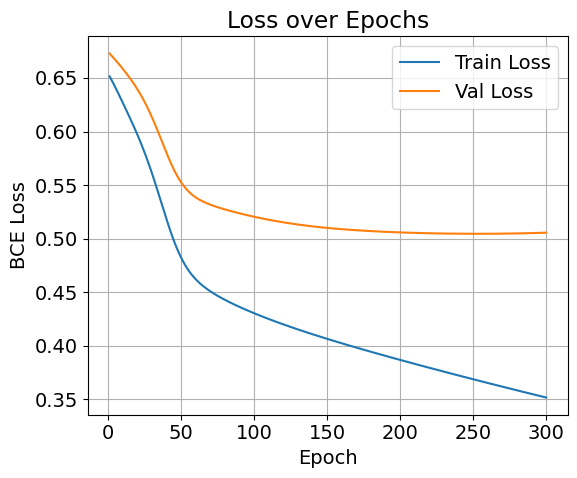

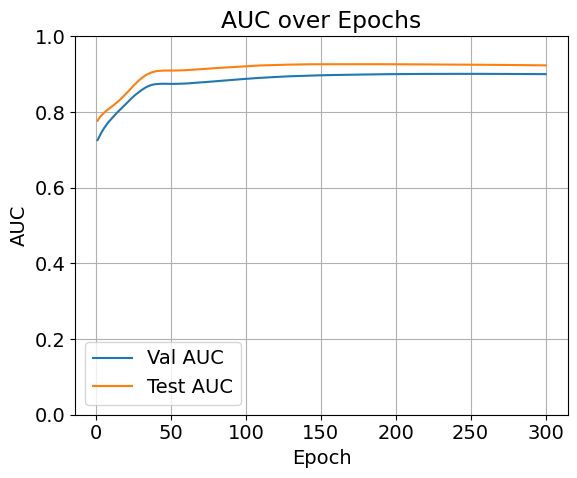

In [13]:
# Main: call training and then plot (outside function)
if __name__ == "__main__":
    # Load dataset (already loaded above)
    print("Starting training for link prediction (NumPy GCN).")
    enc, history = train_linkpred(A, X, epochs=300, batch_size=256, hidden_dim=128, emb_dim=64, lr=0.01)

    # Print summary
    print("\nTraining finished.")
    print("Best validation AUC:", history['best_val_auc'])
    print("Test AUC at best validation:", history['best_test_at_val'])

    # Plot Loss: Train vs Val
    epochs_range = range(1, len(history['train_loss'])+1)
    plt.rcParams.update({'font.size': 14})

    plt.figure(figsize=(6,5))
    plt.plot(epochs_range, history['train_loss'], label="Train Loss", linewidth=1.5)
    plt.plot(epochs_range, history['val_loss'], label="Val Loss", linewidth=1.5)
    plt.title("Loss over Epochs")
    plt.xlabel("Epoch"); plt.ylabel("BCE Loss")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig("linkpred_loss.png", dpi=150)
    print("Saved plot: linkpred_loss.png")

    # Plot AUC: Val / Test
    plt.figure(figsize=(6,5))
    plt.plot(epochs_range, history['val_auc'], label="Val AUC", linewidth=1.5)
    plt.plot(epochs_range, history['test_auc'], label="Test AUC", linewidth=1.5)
    plt.title("AUC over Epochs")
    plt.xlabel("Epoch"); plt.ylabel("AUC")
    plt.ylim(0.0, 1.0)
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig("linkpred_auc.png", dpi=150)
    print("Saved plot: linkpred_auc.png")

    plt.show()
